<a href="https://colab.research.google.com/github/vrundan7/carla-ml-safety/blob/main/odd_coverage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"

In [4]:
import os
print("Contents:", os.listdir(BASE_PATH))

Contents: ['train', 'test-town-01', 'test-fog', 'validation', 'test', 'test-night', 'count_labels.py', 'visualize_dataset.py', 'train_classifiers.py', 'evaluate_classifiers.py', 'model_outputs', '.git', '.gitignore']


KProjectionCoverage Implementation

In [5]:
from dataclasses import dataclass
from itertools import combinations, product
from typing import Any, Dict, Iterable, List, Optional, Tuple, TypeVar
from abc import ABC, abstractmethod

Self = TypeVar("Self")

class Projection:
    """A single k-dimensional projection subspace."""
    def __init__(self, n_values: List[int], names: Optional[List[str]] = None):
        self.n_options = n_values
        self.names = names or []
        self.counts: Dict[Tuple[int], int] = {}
        for point in product(*[range(i) for i in n_values]):
            self.counts[point] = 0

    @property
    def points(self):
        return self.counts.keys()

    def is_covered(self, point):
        return self.counts[point] > 0

    @property
    def n_covered(self):
        return sum(int(c > 0) for c in self.counts.values())

    @property
    def n_points(self):
        return len(self.counts)

    def cover(self, point):
        self.counts[point] += 1

    def reset(self):
        for key in self.counts:
            self.counts[key] = 0

    @property
    def k(self):
        return len(self.n_options)


@dataclass
class KCoverageResult:
    coverage: float
    k: int
    covered: int
    total: int
    scenes: int


class KProjectionCoverage:
    """
    k-Projection Coverage from:
    'Quantitative Projection Coverage for Testing ML-enabled Autonomous Systems'
    by Chih-Hong Cheng et al. (https://arxiv.org/abs/1805.04333)
    """
    def __init__(self, k: int, desc: Dict[str, List[Any]]):
        assert k <= len(desc)
        self.desc = desc
        self.k = k
        self.n_scenes = 0
        self.dims = list(desc.keys())
        self.n_dim_values = [len(desc[v]) for v in self.dims]

        self.dim_value_to_index: Dict[Tuple[str, Any], int] = {}
        for d in self.dims:
            for n, o in enumerate(desc[d]):
                self.dim_value_to_index[(d, o)] = n

        self.projections: Dict[Tuple[int], Projection] = {}
        for c in combinations(range(len(self.dims)), r=self.k):
            self.projections[c] = Projection(
                n_values=[self.n_dim_values[j] for j in c],
                names=[self.dims[j] for j in c],
            )

    def add_scenario(self, scenario: Dict[str, Any]):
        assert len(scenario) == len(self.dims)
        scene = [self.dim_value_to_index[d, scenario[d]] for d in self.dims]
        for c, projection in self.projections.items():
            point = tuple(scene[i] for i in c)
            projection.cover(point)
        self.n_scenes += 1

    def add_scenarios(self, scenarios: Iterable[Dict[str, Any]]):
        for s in scenarios:
            self.add_scenario(s)

    def compute(self) -> KCoverageResult:
        covered = 0
        total = 0
        for projection in self.projections.values():
            total += projection.n_points
            covered += projection.n_covered
        return KCoverageResult(
            coverage=covered / total, k=self.k,
            covered=covered, total=total, scenes=self.n_scenes,
        )

print("✅ KProjectionCoverage loaded.")




✅ KProjectionCoverage loaded.


Define ODD Description

In [6]:
odd_description = {
    "weather": ["clear", "fog", "rain"],
    "lighting": ["day", "night"],
    "town": ["Town01", "Town02"],
    "has_traffic_light": [True, False],
    "has_pedestrian": [True, False],
    "has_vehicle": [True, False],
}

print("ODD Description:")
for dim, values in odd_description.items():
    print(f"  {dim}: {values}")

total_combos = 1
for v in odd_description.values():
    total_combos *= len(v)
print(f"\nTotal ODD combinations: {total_combos}")


ODD Description:
  weather: ['clear', 'fog', 'rain']
  lighting: ['day', 'night']
  town: ['Town01', 'Town02']
  has_traffic_light: [True, False]
  has_pedestrian: [True, False]
  has_vehicle: [True, False]

Total ODD combinations: 96


Extract scenarios from all test splits

In [7]:
import pandas as pd
import yaml

def get_split_conditions(split_dir):
    """Read config.yaml for weather/lighting/town, labels.csv for per-frame labels."""
    config_path = os.path.join(split_dir, ".hydra", "config.yaml")
    labels_path = os.path.join(split_dir, "labels.csv")

    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    sim = config['simulation']
    w = sim['weather']

    # Classify weather
    if w.get('fog_density', 0) >= 50:
        weather = "fog"
    elif w.get('precipitation', 0) >= 50:
        weather = "rain"
    else:
        weather = "clear"

    # Classify lighting
    lighting = "night" if w.get('sun_altitude_angle', 45) <= 0 else "day"

    # Town
    town = sim.get('world_name', 'Town02')

    # Read labels
    df = pd.read_csv(labels_path)

    scenarios = []
    for _, row in df.iterrows():
        scenarios.append({
            "weather": weather,
            "lighting": lighting,
            "town": town,
            "has_traffic_light": bool(row['has_traffic_light']),
            "has_pedestrian": bool(row['has_pedestrian']),
            "has_vehicle": bool(row['has_vehicle']),
        })

    print(f"  {os.path.basename(split_dir)}: weather={weather}, lighting={lighting}, "
          f"town={town}, frames={len(scenarios)}")
    return scenarios

# All test splits
test_splits = [
    f"{BASE_PATH}/test/test",
    f"{BASE_PATH}/test-fog/test-fog",
    f"{BASE_PATH}/test-night/test-night",
    f"{BASE_PATH}/test-town-01/test-town-01",
]

print("Extracting conditions from test splits:\n")
all_scenarios = []
for split_dir in test_splits:
    if os.path.exists(split_dir):
        all_scenarios.extend(get_split_conditions(split_dir))
    else:
        print(f"  ⚠️  Not found: {split_dir}")

print(f"\nTotal test scenarios: {len(all_scenarios)}")


Extracting conditions from test splits:

  test: weather=clear, lighting=day, town=Town02, frames=3600
  test-fog: weather=fog, lighting=day, town=Town02, frames=3600
  test-night: weather=rain, lighting=night, town=Town02, frames=3600
  test-town-01: weather=clear, lighting=day, town=Town01, frames=3600

Total test scenarios: 14400


Compute k-Projection Coverage for k = 1, 2, 3

In [8]:
print("="*70)
print("  k-Projection Coverage Results")
print("="*70)

results = {}
for k in [1, 2, 3]:
    cov = KProjectionCoverage(k=k, desc=odd_description)
    cov.add_scenarios(all_scenarios)
    result = cov.compute()
    results[k] = result

    print(f"\n  k={k}:")
    print(f"    Coverage:       {result.coverage:.4f}  ({result.coverage*100:.1f}%)")
    print(f"    Covered/Total:  {result.covered} / {result.total}")
    print(f"    Scenarios:      {result.scenes}")

# Summary table
print("\n" + "="*70)
print(f"{'k':<5} {'Coverage':<15} {'Covered':<12} {'Total':<12} {'%':<10}")
print("-"*70)
for k, r in results.items():
    print(f"{k:<5} {r.coverage:<15.4f} {r.covered:<12} {r.total:<12} {r.coverage*100:<10.1f}")
print("="*70)



  k-Projection Coverage Results

  k=1:
    Coverage:       1.0000  (100.0%)
    Covered/Total:  13 / 13
    Scenarios:      14400

  k=2:
    Coverage:       0.9143  (91.4%)
    Covered/Total:  64 / 70
    Scenarios:      14400

  k=3:
    Coverage:       0.7800  (78.0%)
    Covered/Total:  156 / 200
    Scenarios:      14400

k     Coverage        Covered      Total        %         
----------------------------------------------------------------------
1     1.0000          13           13           100.0     
2     0.9143          64           70           91.4      
3     0.7800          156          200          78.0      


Show UNCOVERED combinations (k=2)

In [9]:
print("\n" + "="*70)
print("  Uncovered 2-way Combinations")
print("="*70)

cov_k2 = KProjectionCoverage(k=2, desc=odd_description)
cov_k2.add_scenarios(all_scenarios)

dims = list(odd_description.keys())
for i, j in combinations(range(len(dims)), 2):
    dim_i, dim_j = dims[i], dims[j]
    projection = cov_k2.projections[(i, j)]

    uncovered = []
    for point in projection.points:
        if not projection.is_covered(point):
            val_i = odd_description[dim_i][point[0]]
            val_j = odd_description[dim_j][point[1]]
            uncovered.append(f"({val_i}, {val_j})")

    if uncovered:
        print(f"\n  {dim_i} × {dim_j}:")
        for u in uncovered:
            print(f"    ❌ {u}")



  Uncovered 2-way Combinations

  weather × lighting:
    ❌ (clear, night)
    ❌ (fog, night)
    ❌ (rain, day)

  weather × town:
    ❌ (fog, Town01)
    ❌ (rain, Town01)

  lighting × town:
    ❌ (night, Town01)


Visualization

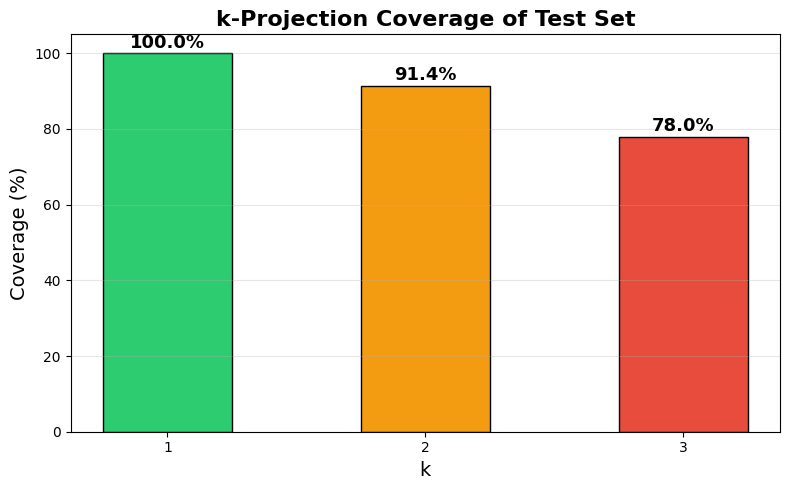

In [10]:
import matplotlib.pyplot as plt

ks = [1, 2, 3]
coverages = [results[k].coverage * 100 for k in ks]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ks, coverages, color=['#2ecc71', '#f39c12', '#e74c3c'],
              edgecolor='black', width=0.5)
ax.set_xlabel('k', fontsize=14)
ax.set_ylabel('Coverage (%)', fontsize=14)
ax.set_title('k-Projection Coverage of Test Set', fontsize=16, fontweight='bold')
ax.set_xticks(ks)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

for bar, cov in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{cov:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
